#### Name: Ben Maxwell

# PHYS 230 Lab Assignment 14

### Monday, March 30, 2026: Chapter 8.1
- First-order differential equations 

In [1]:
# import statements here
import math
import numpy as np
import matplotlib.pyplot as plt

### The problem:

Today we will solve a first-order ordinary differential equation for the velocity of a falling ball with air resistance (assuming linear drag). This equation, assuming vertical motion only and downwards as the positive y-direction, is given as: 

$$\frac{dv}{dt}= g -\frac{b}{m}v $$

The exact solution to this differential equation is: 

$$ v(t) = v_0 e^{-\frac{b}{m}t} + v_{\text{ter}} \left( 1 -  e^{-\frac{b}{m}t} \right) $$


where $v_0$ is the initial velocity and $v_{\text{ter}} = \frac{mg}{b}$ is the terminal velocity. For this problem, we will assume that our 1.0 kg ball is initially at rest, so $v_0 = 0$ at $t=0$, the graviational acceleration $g = 9.8 \text{ m/s}^2$, and the drag coefficient $b = 0.1 \frac{\text{N}}{\text{m/s}}$. 

*don't forget comments in your code cells*

### Part 1: Exact Solution

Calculate the exact solution of $v(t)$ for an array of times. Do this in the following steps: 

#### Step 1: 

Write a function `v(t,b,m,v0)` that takes in an array of times (from $t=0$ to $t=100$ by 2's) and constants $b,m,v_0$ and returns an array of velocities using the equation above. Think about any constants might need to be included inside the function. 

In [35]:
#Defining constants
m = 1. #kg
g = 9.8 #m/s^2
b = 0.1 #N/(m/s)
v0 = 0. #m/s
vter = m*g/b #Given equaiton, m/s

#Creating an array from t = 0 to t = 100
tpts = np.arange(0,101,2)

#Defining function v

def v(t,b,m,v0):
    return v0*np.exp(-b*t/m)+vter*(1-np.exp(-b*t/m))



To begin my code, I start by defining my constants that were all given, which included m, g, b and v0. Then I calculated vter, which was given to be m*g/b. Afterwards, I created a range from 0 to 100 which counted by 2s using np.arange for the points for t. Finally, I defined a function v which takes t, b, m, and v0 to calculate the velocity at a given point based on the eqatuon above. 

### <font color='purple'> Comments </font> 

<font color='purple'> nice comments! oh you even did a markdown! since b,m, and v0 are variables fed into the `v` function, should define vter inside your function 

why are constants here? supposed to be defined in next step  </font> 


#### Step 2: 

Define the array of times $t$, or whatever variable you want to use, and your necessary constants, and calculate the array of velocities using your function. 

In [36]:
#Calculating the velocity at each time
vpts = v(tpts, b, m, v0)

I accidentally defined all my constants in part one. All I did here was use all of my constants to calculate the velocities at different times.

### <font color='purple'> Comments </font> 

<font color='purple'> says to define all necessary constants here - oh i see you acknolwedged it. Could have just moved them? easy copy and paste.... </font> 


#### Step 3: 
Make a plot of the results. 

Text(0, 0.5, 'v(t)')

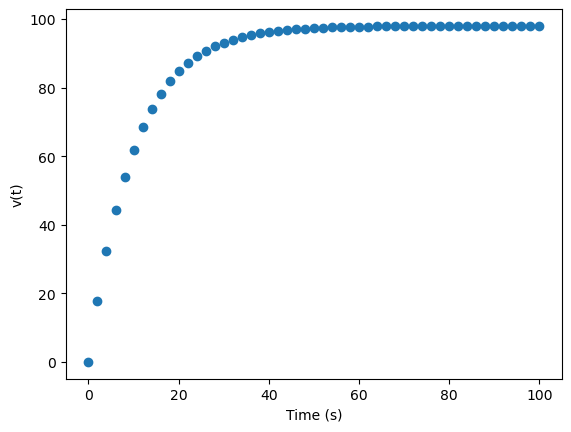

In [37]:
#Plotting the results
plt.scatter(tpts,vpts)
plt.xlabel("Time (s)")
plt.ylabel("v(t)")

All this does is plot the tpts against the vpts and then adds labels as needed. It uses plt.scatter to plot. 

### <font color='purple'> Comments </font> 

<font color='purple'> always include `plt.show()` at the end of your graph so that all updates show up </font> 


### Part 2: Euler Method

Calculate the solution for the same array of times using the Euler method instead. 

#### Step 1: 

Write two functions: `f(v)` that calculate the result of the differential equation for vertical, linear projectile motion, and `euler(t,h,v0,f)` that takes in an array $t$ of times in the same range as part 1 and using a defined $h$ value,initial conditions, and the differential equation returns an *array*. 

In [38]:
#Defining f(v)
def f(v1):
    return g-(b*v1/m)

#Defining euler
def euler(t,h,v0,f):
    for i in range(len(t)): #Goes through array t
        vpts2[i] = v0 #Sets the point equal to the inital velocity (and sets all points in the future)
        v0 += h*f(v0) #Updates the velocity according to euler. 




In this section, I defined the function f(v) to just return the equation given above. The, I defined euler function, which starts by going through the range of a given array t. For each value, it sets the velocity at that point equal it the current velocity, which starts as v0. Then at each value, it updates the velocity according to euler by adding hf(v,t) to it. 

### <font color='purple'> Comments </font> 

<font color='purple'> you don't return anything in your `euler` functoin? should create the vpts array in the function and then return it -> says it needs to return an array </font> 


#### Step 2

Calculate the array of velocities usig your `euler` function and make a plot of the results with the exact calculation on the **same** graph (put both results on the same graph here).

Text(0, 0.5, 'v(t)')

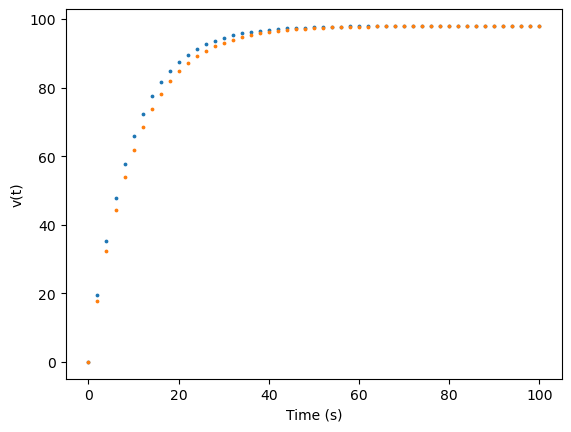

In [40]:
#Defing my constantst
tstart = 0. #s
tend = 100. #s
nsteps = 50 #Number of steps
h = (tend-tstart)/nsteps

#Making an array for t
t = np.arange(tstart, tend+h, h)
vpts2 = np.zeros(len(tpts))

#Calculating the array for the vpts
euler(t, h, v0, f)

#Plotting the results.
plt.scatter(t,vpts2,s=3)
plt.scatter(tpts,vpts,s=3)
plt.xlabel("Time (s)")
plt.ylabel("v(t)")

I started by setting my constants, which was t starting at 0s and ending at 100, with about 100 steps. Then, I calculated h by finding tend-tstart of number of steps. Then I created an array from tstart to tend+h, going by steps of h. I alsp created an empty array for vpts called vpts2. Then, I called on the euler function, using my defined t, h, v0, and f. Using this, I then plotted it using plt.scatter, with the blue being my euler and the orange being the exact value. This graph shows the euler is quite accurate compared to the actual solution. 

### <font color='purple'> Comments </font> 

<font color='purple'> oh you need a legend! how do we know which plots are which without looking at code or markdown? should be able to tell from graph. also, don't forget plt.show() </font> 


### Part 3: Fourth-order Runge-Kutta Method

Calculate the solution for the same array of times using the Runge-Kutta method instead. For this, define a function `RK4(t,h,v0,f)` that takes in an array of times, initial velocity, $h$, initial conditions, and differential equation function. 

Plot this as well as the exact and Euler solutions on the **same** graph as well. 

Text(0, 0.5, 'v(t)')

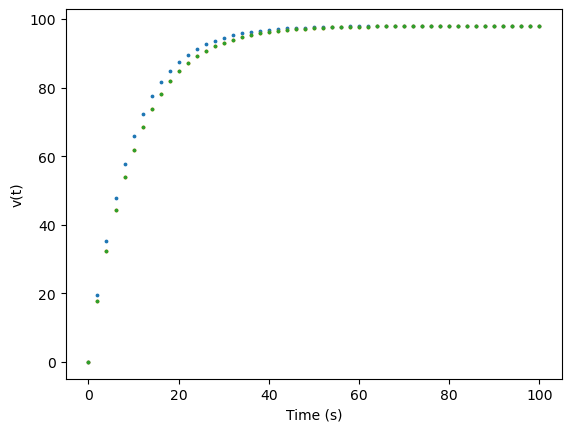

In [46]:
#Defining RK4
def RK4(t, h, v0, f):
    for i in range(len(t)):
        vrk4[i] = v0
        k1 = h*f(v0) #Calculating k1
        k2 = h*f(v0+0.5*k1) #Calculating k2
        k3 = h*f(v0+0.5*k2) #Calculating k3
        k4 = h*f(v0+k3) #Calculating k4
        v0 += (k1+2*k2+2*k3+k4) / 6 #Updating the velocity

#Making an array for t
rkt = np.arange(tstart, tend+h, h)
vrk4 = np.zeros(len(rkt))

#Calculating the array for the vpts
RK4(rkt, h, v0, f)

#Plotting the results.
plt.scatter(t,vpts2,s=3)
plt.scatter(tpts,vpts,s=3)
plt.scatter(rkt,vrk4,s=3)
plt.xlabel("Time (s)")
plt.ylabel("v(t)")

To begin my code, I start by defining my function. In the function, it goes through all values of t, and at each values sets the respective value ofv equal to the current velocity. Then it updates the velocity by calculating k1, k2, k3, and k4 as given in rk4. Consider there is no time dependence in the function. Next, I made an array for rkt which starts at the starting time and ends at the ending time and goes through by h. I also made an empty array for vrk4. I then called upon the function using rkt (which was just defined), h, v0, and f (all others defined previously). Then I graphed and labeled everything. The colors are the same, except RK4 is green. This is incredibly accurate as it is on orange. 

### <font color='purple'> Comments </font> 

<font color='purple'>we can't see one of your points -> since doing scatter, could make it bigger by changing `s`. need a legend too and plt.show(). nice job otherwise!  </font> 


### Part 4: Markdown comparision

What can you conclude about the results? Do they all agree? (Explain in a markdown cell below - you will need to change it to a markdown cell first)

All of the results are consistent with each other, with the eulers being less accurate, and the RK4 being incredibly accurate based on the graph. RK4 (green) and the real answer (orange) are indistinguishable from each other its so accurate. 

### Part 5: Adjust

Try using smaller and bigger time steps to see the effect of improving your approximations (Euler and/or Runge-Kutta). Explain your results and process in markdown. 

Text(0, 0.5, 'v(t)')

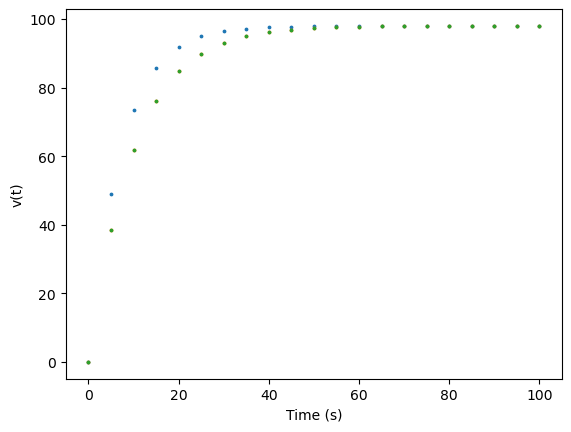

In [51]:
#Defing my constantst
tstart = 0. #s
tend = 100. #s
nsteps = 20 #Number of steps
h = (tend-tstart)/nsteps

#Creating an array from t = 0 to t = 100
tpts = np.arange(tstart,tend+h,h)
vpts = v(tpts, b, m, v0)

#Making an array for t
t = np.arange(tstart, tend+h, h)
vpts2 = np.zeros(len(tpts))

#Calculating the array for the vpts
euler(t, h, v0, f)

#Making an array for t
rkt = np.arange(tstart, tend+h, h)
vrk4 = np.zeros(len(rkt))

#Calculating the array for the vpts
RK4(rkt, h, v0, f)

#Plotting the results.
plt.scatter(t,vpts2,s=3)
plt.scatter(tpts,vpts,s=3)
plt.scatter(rkt,vrk4,s=3)
plt.xlabel("Time (s)")
plt.ylabel("v(t)")

#### Explanation Markdown Cell: 
I tested a couple different values for the number of steps. At nsteps=1000, all the graphs look exactly the same, showing accuracy for both Euler and RK4. At lower numbers such as nsteps=20, eulers is much less accurate, where RK4 is still just as accurate as it has been.

### <font color='purple'> Comments </font> 

<font color='purple'> where is the Nsteps = 1000 result? should keep both so I can see your results. Just copy and paste your code into another cell so I can see these results </font> 
